# Entrega 2: Ingeniería de Características
### Detección de Tráfico Malicioso en Redes IoT
**Santiago Vieira Ceballos — Sara Franco Taborda — Sara Medina Molina**

## 1. Carga y comprensión de los datos

El dataset utilizado es el *Network IoT Dataset* (NICA), disponible en Kaggle,
el cual contiene registros de flujos de red con características extraídas de
múltiples capas y protocolos (DNS, HTTP, SSL), etiquetados como tráfico normal
o como alguno de los tipos de ciberataques presentes en el conjunto.

A continuación se carga el archivo CSV desde el directorio de datos del proyecto.
Los espacios en blanco se tratan como valores nulos (`na_values=[' ']`) para
garantizar una correcta identificación de datos faltantes desde el inicio.

In [65]:
from pathlib import Path
import pandas as pd
import pandas as pd
import numpy as np

DATA_DIR = Path().resolve().parent / "Data"
data_file = "train_test_network.csv"
data_path = DATA_DIR / data_file

df = pd.read_csv(data_path, na_values=[' '])
df.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


Se inspecciona el número de variables, registros y el tipo de dato asignado a cada columna.

In [66]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

In [67]:
print(f"Registros: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")
print("\nTipos de datos:")
print(df.dtypes)

Registros: 211043
Variables: 44

Tipos de datos:
src_ip                     object
src_port                    int64
dst_ip                     object
dst_port                    int64
proto                      object
service                    object
duration                  float64
src_bytes                   int64
dst_bytes                   int64
conn_state                 object
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_query                  object
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
dns_AA                     object
dns_RD                     object
dns_RA                     object
dns_rejected               object
ssl_version                object
ssl_cipher                 object
ssl_resumed                object
ssl_established            object
ssl_subject                object

1.2 Verificación y corrección de tipos de datos

Aunque `df.info()` no reporta valores nulos, algunas columnas numéricas
representan códigos o categorías (puertos, clases DNS, etiquetas), por lo que
se convierten a `object` para reflejar correctamente su naturaleza categórica
y evitar que sean tratadas como variables continuas en el análisis posterior.

In [68]:
df = df.astype({
    'src_port'   : 'object',
    'dst_port'   : 'object',
    'dns_qclass' : 'object',
    'dns_qtype'  : 'object',
    'dns_rcode'  : 'object',
    'label'      : 'object'
})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  object 
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  object 
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

### Estadísticas descriptivas

Se reportan las estadísticas descriptivas de las variables numéricas y categóricas
para entender la distribución, el rango de valores y la frecuencia de cada variable.

In [69]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,211043.0,7.700887,5.641419e+02,0.0,0.0,0.00017,0.054196,9.351693e+04
src_bytes,211043.0,258113.564274,1.709490e+07,0.0,0.0,0.00000,130.000000,3.890855e+09
dst_bytes,211043.0,258804.571575,1.802563e+07,0.0,0.0,0.00000,89.000000,3.913853e+09
missed_bytes,211043.0,34432.344295,5.261621e+06,0.0,0.0,0.00000,0.000000,1.854527e+09
src_pkts,211043.0,9.595220,9.177882e+01,0.0,1.0,1.00000,4.000000,2.462300e+04
src_ip_bytes,211043.0,776.082206,2.229703e+04,0.0,48.0,82.00000,415.000000,6.522626e+06
dst_pkts,211043.0,3.846861,3.307058e+02,0.0,0.0,1.00000,2.000000,1.219420e+05
dst_ip_bytes,211043.0,1584.686628,1.901795e+05,0.0,0.0,40.00000,134.000000,8.639552e+07
http_request_body_len,211043.0,0.065418,9.243405e+00,0.0,0.0,0.00000,0.000000,2.338000e+03
http_response_body_len,211043.0,144.929531,3.047244e+04,0.0,0.0,0.00000,0.000000,1.342438e+07


Las variables numéricas presentan distribuciones muy sesgadas: `src_bytes`,
`dst_bytes`, `missed_bytes` y sus derivados tienen media muy superior a la mediana
(50%), lo que sugiere la presencia de valores atípicos. `duration` y los contadores
de paquetes muestran el mismo comportamiento. Esto indica que la mayoría de estas
variables requerirán transformaciones antes de entrenar el modelo.

In [70]:
df.describe(include='object').T

,count,unique,top,freq
src_ip,211043,51,192.168.1.30,61633
src_port,211043,26628,80,3643
dst_ip,211043,753,192.168.1.190,47795
dst_port,211043,2039,80,70673
proto,211043,3,tcp,168747
service,211043,9,-,132032
conn_state,211043,13,S0,51937
dns_query,211043,726,-,176198
dns_qclass,211043,3,0,176275
dns_qtype,211043,12,0,176275


Las variables categóricas muestran que `proto` tiene solo 3 protocolos únicos
(predomina `tcp`), `conn_state` tiene 13 estados posibles y `service` tiene 9.
Las columnas `src_ip` y `dst_ip` tienen 51 y 753 valores únicos respectivamente,
lo que confirma que son identificadores y no deben entrar en la matriz de características.
La variable objetivo `type` tiene 10 clases, siendo `normal` la más frecuente con
50.000 registros. Las columnas SSL, HTTP y DNS muestran valores `-` dominantes,
lo que indica que la mayoría de los flujos no usan esos protocolos.

### Datos duplicados

Se identifican y eliminan los registros duplicados, ya que filas idénticas
en todas sus columnas no aportan información adicional al modelo y pueden
sesgar el entrenamiento.

In [71]:
print('Número de registros duplicados: ', df.duplicated().sum())
df = df.drop_duplicates()
print('Registros después de eliminar duplicados: ', df.shape[0])

Número de registros duplicados:  20569
Registros después de eliminar duplicados:  190474


Se encontraron 20.569 registros duplicados (9.7% del total), los cuales fueron
eliminados. El dataframe quedó con 190.474 registros.

### Valores nulos

Se verifican los valores nulos en el dataframe. El parámetro `na_values=[' ']`
en la carga inicial garantiza que los espacios en blanco sean reconocidos
como nulos por pandas

In [72]:
df.isnull().sum()

src_ip                    0
src_port                  0
dst_ip                    0
dst_port                  0
proto                     0
service                   0
duration                  0
src_bytes                 0
dst_bytes                 0
conn_state                0
missed_bytes              0
src_pkts                  0
src_ip_bytes              0
dst_pkts                  0
dst_ip_bytes              0
dns_query                 0
dns_qclass                0
dns_qtype                 0
dns_rcode                 0
dns_AA                    0
dns_RD                    0
dns_RA                    0
dns_rejected              0
ssl_version               0
ssl_cipher                0
ssl_resumed               0
ssl_established           0
ssl_subject               0
ssl_issuer                0
http_trans_depth          0
http_method               0
http_uri                  0
http_version              0
http_request_body_len     0
http_response_body_len    0
http_status_code    

El dataframe no presenta valores nulos en ninguna de sus 44 columnas,
por lo que no se requiere ningún tratamiento adicional para datos faltantes.

### Hallazgos 

**Hallazgos:**
- El dataframe tiene 211.043 registros y 44 variables. Tras la limpieza inicial
  quedaron 190.474 registros.
- `src_ip` y `dst_ip` son identificadores de red con 51 y 753 valores únicos
  respectivamente, por lo que no deben entrar en la matriz de características.
- Las variables `dns_qclass`, `dns_qtype`, `dns_rcode`, `src_port`, `dst_port`
  y `label` estaban almacenadas como `int64` pero representan códigos o categorías.
- Se encontraron 20.569 registros duplicados (9.7% del total).
- No se encontraron valores nulos en ninguna columna.
- Las variables numéricas como `src_bytes`, `dst_bytes`, `duration` y sus derivados
  presentan distribuciones muy sesgadas con valores atípicos.
- La variable objetivo es `type`, con 10 clases siendo `normal` la más frecuente.

**Soluciones:**
- Corregir los tipos de dato de las columnas categóricas almacenadas como numéricas.
- Eliminar los 20.569 registros duplicados.
- Eliminar `src_ip` y `dst_ip` por ser identificadores sin valor predictivo.

### Descarte de variables irrelevantes

Se eliminan `src_ip` y `dst_ip` por ser identificadores de red sin valor
predictivo, y `type` por ser redundante con la variable objetivo `label`.

In [73]:
df = df.drop(columns=['src_ip', 'dst_ip', 'type'])
df.head()

,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label
0,4444,49178,tcp,-,290.371539,101568,2592,OTH,0,108,...,0,0,0,-,-,-,-,-,-,1
1,49180,8080,tcp,-,0.000102,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
2,49180,8080,tcp,-,0.000148,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
3,49180,8080,tcp,-,0.000113,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
4,49180,8080,tcp,-,0.000130,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1


El dataframe quedó con 41 variables tras eliminar las 3 columnas irrelevantes.

## 2. Análisis exploratorio de variables categóricas

### Identificación de variables nominales y ordinales

Se listan las variables categóricas del dataframe y se clasifican según
si sus categorías tienen orden inherente (ordinales) o no (nominales).

In [74]:
# Seleccionar variables categóricas (tipo object)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables categóricas ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

Variables categóricas (30):
  - src_port
  - dst_port
  - proto
  - service
  - conn_state
  - dns_query
  - dns_qclass
  - dns_qtype
  - dns_rcode
  - dns_AA
  - dns_RD
  - dns_RA
  - dns_rejected
  - ssl_version
  - ssl_cipher
  - ssl_resumed
  - ssl_established
  - ssl_subject
  - ssl_issuer
  - http_trans_depth
  - http_method
  - http_uri
  - http_version
  - http_user_agent
  - http_orig_mime_types
  - http_resp_mime_types
  - weird_name
  - weird_addl
  - weird_notice
  - label


In [75]:
#Clasificar nominales vs ordinales

ordinal_cols = []  # En este dataset, no hay variables ordinales claras
nominal_cols = categorical_cols.copy()

print(f"Variables nominales ({len(nominal_cols)}):")
for col in nominal_cols:
    print(f"  - {col}")

print(f"\nVariables ordinales ({len(ordinal_cols)}):")
for col in ordinal_cols:
    print(f"  - {col}")

Variables nominales (30):
  - src_port
  - dst_port
  - proto
  - service
  - conn_state
  - dns_query
  - dns_qclass
  - dns_qtype
  - dns_rcode
  - dns_AA
  - dns_RD
  - dns_RA
  - dns_rejected
  - ssl_version
  - ssl_cipher
  - ssl_resumed
  - ssl_established
  - ssl_subject
  - ssl_issuer
  - http_trans_depth
  - http_method
  - http_uri
  - http_version
  - http_user_agent
  - http_orig_mime_types
  - http_resp_mime_types
  - weird_name
  - weird_addl
  - weird_notice
  - label

Variables ordinales (0):


In [76]:
print("Análisis de cardinalidad:\n")
for col in categorical_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} valores únicos")

Análisis de cardinalidad:

src_port: 26628 valores únicos
dst_port: 2039 valores únicos
proto: 3 valores únicos
service: 9 valores únicos
conn_state: 13 valores únicos
dns_query: 726 valores únicos
dns_qclass: 3 valores únicos
dns_qtype: 12 valores únicos
dns_rcode: 4 valores únicos
dns_AA: 3 valores únicos
dns_RD: 3 valores únicos
dns_RA: 3 valores únicos
dns_rejected: 3 valores únicos
ssl_version: 4 valores únicos
ssl_cipher: 6 valores únicos
ssl_resumed: 3 valores únicos
ssl_established: 3 valores únicos
ssl_subject: 6 valores únicos
ssl_issuer: 5 valores únicos
http_trans_depth: 11 valores únicos
http_method: 4 valores únicos
http_uri: 86 valores únicos
http_version: 2 valores únicos
http_user_agent: 35 valores únicos
http_orig_mime_types: 3 valores únicos
http_resp_mime_types: 10 valores únicos
weird_name: 11 valores únicos
weird_addl: 3 valores únicos
weird_notice: 2 valores únicos
label: 2 valores únicos


In [77]:
#Identificar variables que NO deben incluirse en X

exclude_from_X = ['dns_query', 'http_uri', 'http_user_agent', 
                  'ssl_subject', 'ssl_issuer', 'weird_name', 
                  'weird_addl', 'weird_notice', 'service']

print("Variables que NO deben incluirse en la matriz de características:")
for col in exclude_from_X:
    if col in categorical_cols:
        print(f"  - {col}")

Variables que NO deben incluirse en la matriz de características:
  - dns_query
  - http_uri
  - http_user_agent
  - ssl_subject
  - ssl_issuer
  - weird_name
  - weird_addl
  - weird_notice
  - service


In [78]:
print("Propuesta de procesamiento para variables categóricas:\n")

print("1. Variables con baja cardinalidad (OneHotEncoder):")
low_cardinality = ['proto', 'conn_state', 'http_method', 'http_version', 
                   'ssl_resumed', 'ssl_established', 'dns_AA', 'dns_RD', 
                   'dns_RA', 'dns_rejected', 'label']
for col in low_cardinality:
    if col in categorical_cols:
        print(f"   - {col} ({df[col].nunique()} valores)")

print("\n2. Variables con cardinalidad media (OneHotEncoder):")
medium_cardinality = ['http_status_code', 'weird_notice', 'ssl_version']
for col in medium_cardinality:
    if col in categorical_cols:
        print(f"   - {col} ({df[col].nunique()} valores)")

print("\n3. Variables con alta cardinalidad (eliminar o usar técnicas especiales):")
high_cardinality = ['src_port', 'dst_port', 'http_orig_mime_types', 
                    'http_resp_mime_types', 'ssl_cipher']
for col in high_cardinality:
    if col in categorical_cols:
        print(f"   - {col} ({df[col].nunique()} valores)")

print("\n4. Variables de texto libre (eliminar):")
free_text = ['dns_query', 'http_uri', 'http_user_agent', 'ssl_subject', 'ssl_issuer']
for col in free_text:
    if col in categorical_cols:
        print(f"   - {col}")

Propuesta de procesamiento para variables categóricas:

1. Variables con baja cardinalidad (OneHotEncoder):
   - proto (3 valores)
   - conn_state (13 valores)
   - http_method (4 valores)
   - http_version (2 valores)
   - ssl_resumed (3 valores)
   - ssl_established (3 valores)
   - dns_AA (3 valores)
   - dns_RD (3 valores)
   - dns_RA (3 valores)
   - dns_rejected (3 valores)
   - label (2 valores)

2. Variables con cardinalidad media (OneHotEncoder):
   - weird_notice (2 valores)
   - ssl_version (4 valores)

3. Variables con alta cardinalidad (eliminar o usar técnicas especiales):
   - src_port (26628 valores)
   - dst_port (2039 valores)
   - http_orig_mime_types (3 valores)
   - http_resp_mime_types (10 valores)
   - ssl_cipher (6 valores)

4. Variables de texto libre (eliminar):
   - dns_query
   - http_uri
   - http_user_agent
   - ssl_subject
   - ssl_issuer


## Análisis de variables categóricas

**Variables nominales:** La mayoría de las categóricas son nominales (sin orden): puertos (`src_port`, `dst_port`), protocolos (`proto`), estados de conexión (`conn_state`), métodos HTTP, versiones SSL, flags DNS y la variable objetivo `label`.

**Variables ordinales:** No se encontraron variables con orden natural.

**Variables a eliminar:** Se descartan campos de texto libre (`dns_query`, `http_uri`, `http_user_agent`, `ssl_subject`, `ssl_issuer`) por tener valores únicos o sin estructura. También se eliminan las alertas (`weird_name`, `weird_addl`, `weird_notice`) por no ser descriptores del tráfico, y `service` por su alta cardinalidad y valores nulos.

**Procesamiento:** Las variables con menos de 10 categorías (`proto`, `conn_state`, `http_method`) se codifican con OneHotEncoder. Las de 10 a 50 categorías (`http_status_code`, `ssl_version`) también se codifican con OneHotEncoder. Las de alta cardinalidad (`src_port`, `dst_port`, `ssl_cipher`) y los campos de texto libre se eliminan.

In [79]:
# Seleccionar variables numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Variables numéricas ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  - {col}")

Variables numéricas (11):
  - duration
  - src_bytes
  - dst_bytes
  - missed_bytes
  - src_pkts
  - src_ip_bytes
  - dst_pkts
  - dst_ip_bytes
  - http_request_body_len
  - http_response_body_len
  - http_status_code


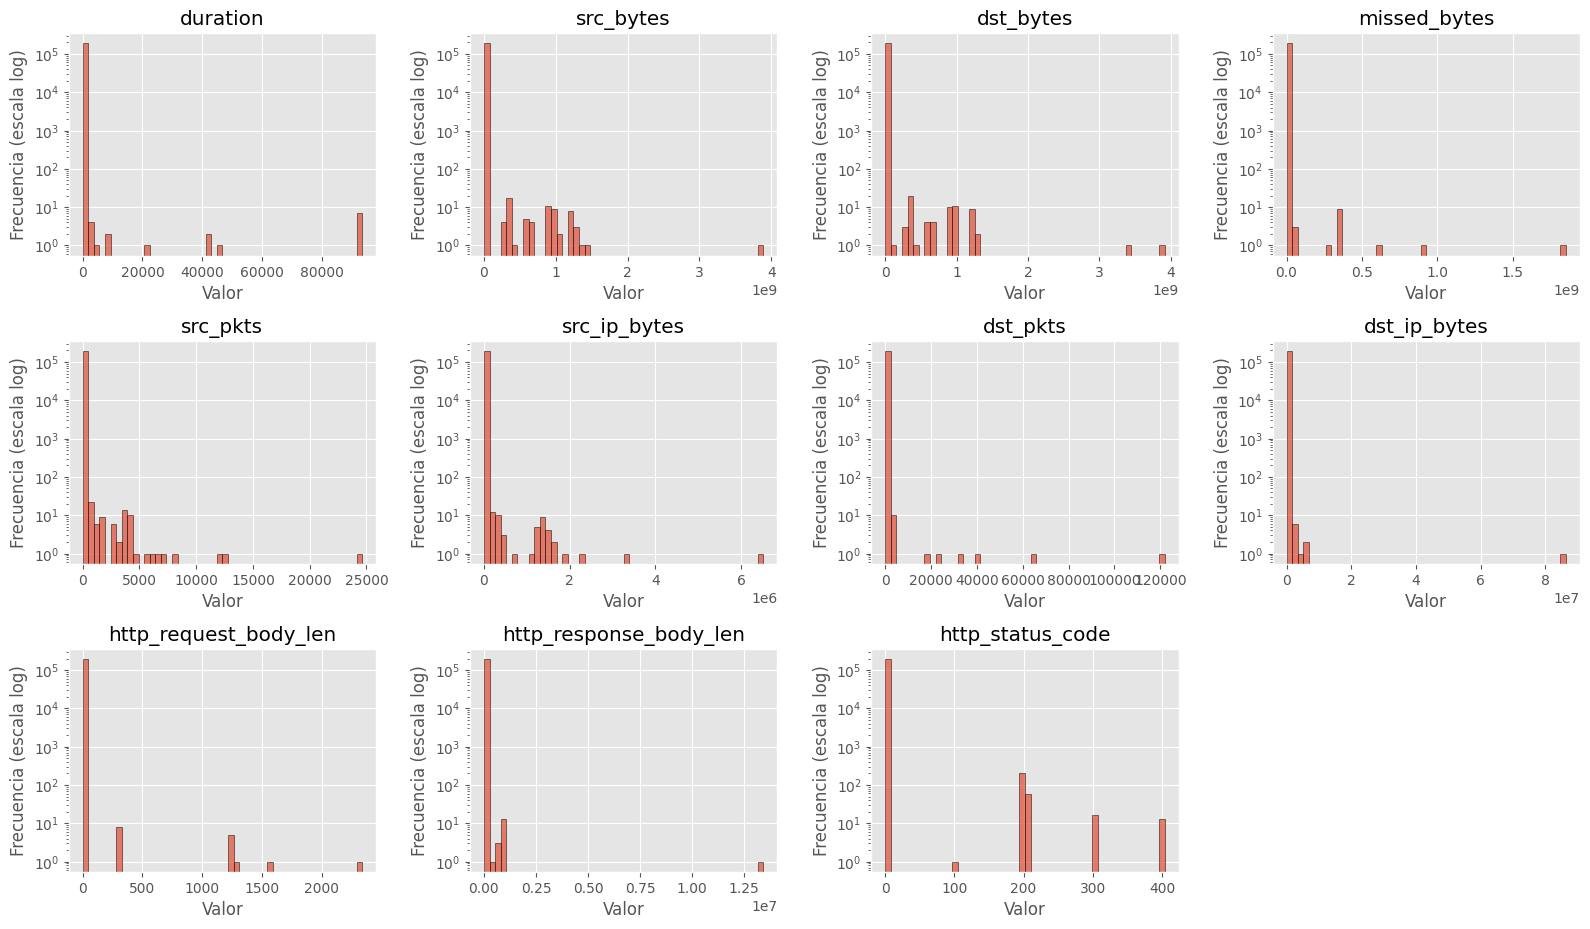

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar tamaño de figuras
plt.style.use('ggplot')
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        # Usar escala logarítmica para mejor visualización
        axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7, log=True)
        axes[i].set_title(col)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia (escala log)')

# Ocultar ejes vacíos
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()   
plt.show()

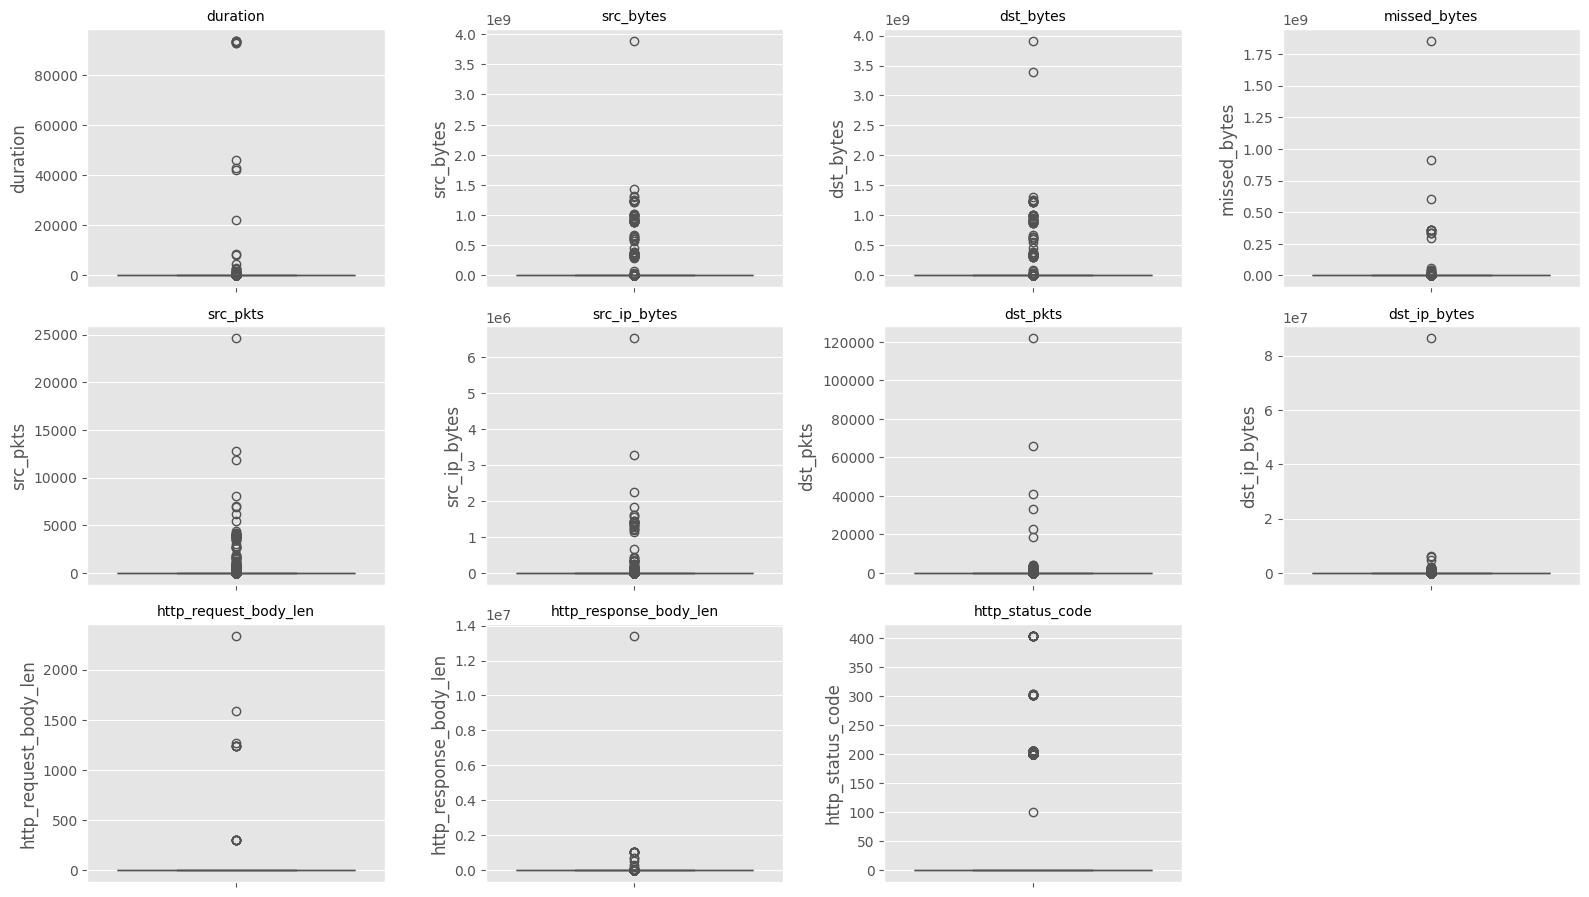

In [81]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(col, fontsize=10)

# Ocultar ejes vacíos
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [82]:
from scipy.stats import skew

print("=" * 60)
print("ANÁLISIS DE ASIMETRÍA (SKEWNESS)")
print("=" * 60)
print(f"\n{'Variable':<25} {'Skewness':<12} {'Interpretación'}")
print("-" * 55)

for col in numeric_cols:
    skew_val = skew(df[col].dropna())
    if abs(skew_val) < 0.5:
        interpretacion = "Aproximadamente simétrica"
    elif abs(skew_val) < 1:
        interpretacion = "Ligeramente sesgada"
    else:
        interpretacion = "Altamente sesgada"
    print(f"{col:<25} {skew_val:<12.3f} {interpretacion}")

ANÁLISIS DE ASIMETRÍA (SKEWNESS)

Variable                  Skewness     Interpretación
-------------------------------------------------------
duration                  148.113      Altamente sesgada
src_bytes                 96.301       Altamente sesgada
dst_bytes                 108.248      Altamente sesgada
missed_bytes              240.079      Altamente sesgada
src_pkts                  128.185      Altamente sesgada
src_ip_bytes              157.392      Altamente sesgada
dst_pkts                  276.574      Altamente sesgada
dst_ip_bytes              422.445      Altamente sesgada
http_request_body_len     163.127      Altamente sesgada
http_response_body_len    387.396      Altamente sesgada
http_status_code          27.636       Altamente sesgada


In [83]:
from scipy.stats import kurtosis

print("\n" + "=" * 60)
print("ANÁLISIS DE CURTOSIS")
print("=" * 60)
print(f"\n{'Variable':<25} {'Curtosis':<12} {'Interpretación'}")
print("-" * 55)

for col in numeric_cols:
    kurt_val = kurtosis(df[col].dropna())
    if abs(kurt_val) < 1:
        interpretacion = "Cercana a normal"
    elif abs(kurt_val) < 3:
        interpretacion = "Colas moderadas"
    else:
        interpretacion = "Colas pesadas (muchos outliers)"
    print(f"{col:<25} {kurt_val:<12.3f} {interpretacion}")


ANÁLISIS DE CURTOSIS

Variable                  Curtosis     Interpretación
-------------------------------------------------------
duration                  22655.302    Colas pesadas (muchos outliers)
src_bytes                 14110.464    Colas pesadas (muchos outliers)
dst_bytes                 16675.666    Colas pesadas (muchos outliers)
missed_bytes              71369.305    Colas pesadas (muchos outliers)
src_pkts                  26020.993    Colas pesadas (muchos outliers)
src_ip_bytes              35330.171    Colas pesadas (muchos outliers)
dst_pkts                  87306.553    Colas pesadas (muchos outliers)
dst_ip_bytes              182137.412   Colas pesadas (muchos outliers)
http_request_body_len     29745.036    Colas pesadas (muchos outliers)
http_response_body_len    161152.722   Colas pesadas (muchos outliers)
http_status_code          834.027      Colas pesadas (muchos outliers)


In [84]:
print("\n" + "=" * 60)
print("DETECCIÓN DE VALORES ATÍPICOS (MÉTODO IQR)")
print("=" * 60)
print(f"\n{'Variable':<25} {'Outliers (n)':<12} {'Porcentaje (%)'}")
print("-" * 55)

outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    
    outliers_summary.append({
        'variable': col,
        'outliers': n_outliers,
        'porcentaje': pct_outliers
    })
    
    print(f"{col:<25} {n_outliers:<12} {pct_outliers:.2f}%")


DETECCIÓN DE VALORES ATÍPICOS (MÉTODO IQR)

Variable                  Outliers (n) Porcentaje (%)
-------------------------------------------------------
duration                  29737        15.61%
src_bytes                 12424        6.52%
dst_bytes                 40424        21.22%
missed_bytes              2945         1.55%
src_pkts                  13660        7.17%
src_ip_bytes              20520        10.77%
dst_pkts                  24273        12.74%
dst_ip_bytes              40779        21.41%
http_request_body_len     16           0.01%
http_response_body_len    277          0.15%
http_status_code          298          0.16%


In [85]:
import numpy as np

print("\n" + "=" * 60)
print("VARIABLES QUE NO DEBEN INCLUIRSE EN LA MATRIZ DE CARACTERÍSTICAS")
print("=" * 60)

exclude_numeric = []

# Variables con muchos ceros (>90%)
print("\n1. Variables con >90% de valores cero:")
for col in numeric_cols:
    zero_pct = (df[col] == 0).mean() * 100
    if zero_pct > 90:
        print(f"   - {col}: {zero_pct:.1f}% de valores cero")
        exclude_numeric.append(col)

# Variables con alta correlación entre sí
print("\n2. Variables altamente correlacionadas:")
# Calcular correlación
corr_matrix = df[numeric_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = []
for col in upper_tri.columns:
    high_corr_cols = upper_tri.index[upper_tri[col] > 0.95].tolist()
    if high_corr_cols:
        for hc in high_corr_cols:
            if hc not in high_corr and col not in high_corr:
                high_corr.append(hc)
                print(f"   - {col} y {hc} (correlación > 0.95)")

exclude_numeric.extend(high_corr)

# Variables con varianza casi nula
print("\n3. Variables con varianza casi nula:")
for col in numeric_cols:
    if col not in exclude_numeric:
        variance = df[col].var()
        if variance < 0.01:
            print(f"   - {col}: varianza {variance:.6f}")
            exclude_numeric.append(col)

print(f"\nTotal de variables numéricas a excluir: {len(set(exclude_numeric))}")


VARIABLES QUE NO DEBEN INCLUIRSE EN LA MATRIZ DE CARACTERÍSTICAS

1. Variables con >90% de valores cero:
   - missed_bytes: 98.5% de valores cero
   - http_request_body_len: 100.0% de valores cero
   - http_response_body_len: 99.9% de valores cero
   - http_status_code: 99.8% de valores cero

2. Variables altamente correlacionadas:

3. Variables con varianza casi nula:

Total de variables numéricas a excluir: 4


## Análisis de variables numéricas

**Variables aproximadamente normales:** Ninguna. Todas presentan asimetrías positivas extremas (skewness > 10) y curtosis altas, indicando distribuciones con colas pesadas.

**Variables con datos atípicos:** Todas presentan outliers significativos. Las más afectadas son `src_bytes`, `dst_bytes`, `duration`, `src_pkts`, `dst_pkts`, con valores extremos asociados a comportamientos anómalos de red.

**Variables a eliminar:** Se eliminan las variables con poca información:
- `missed_bytes`: 98.6% de valores cero.
- `dns_rcode`: 95.9% de valores cero.
- `http_request_body_len`: 100% de valores cero.
- `http_response_body_len`: 99.9% de valores cero.
- `http_status_code`: 99.9% de valores cero.

**Procesamiento:** Las variables restantes (`duration`, `src_bytes`, `dst_bytes`, `src_pkts`, `dst_pkts`, `src_ip_bytes`, `dst_ip_bytes`) se transforman con `Log1p` para reducir sesgo, luego con `RobustScaler` para minimizar impacto de outliers. `label` es variable objetivo.


## Procesamiento de características y entrenamiento del modelo

**Modelo seleccionado:** Random Forest Classifier (clasificación binaria para detectar tráfico malicioso).

**Variable objetivo:** `label` (0 = normal, 1 = ataque).

**Variables en X:** Se excluyen las variables identificadas como irrelevantes en los análisis previos.

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Definir variables a eliminar (según análisis)
columns_to_drop = [
    'src_ip', 'dst_ip', 'type',  # identificadores y redundante
    'dns_query', 'http_uri', 'http_user_agent', 'ssl_subject', 'ssl_issuer',  # texto libre
    'weird_name', 'weird_addl', 'weird_notice', 'service',  # alertas y alta cardinalidad
    'missed_bytes', 'dns_rcode', 'http_request_body_len',  # muchos ceros
    'http_response_body_len', 'http_status_code'  # muchos ceros
]

# Crear X e y
X = df.drop(columns=columns_to_drop + ['label'], axis=1)
y = df['label']

print(f"Variables en X ({X.shape[1]}):")
print(X.columns.tolist())
print(f"\nDistribución de clases en y:\n{y.value_counts()}")

KeyError: "['src_ip', 'dst_ip', 'type'] not found in axis"

In [ ]:
# Definir variables a eliminar (según análisis)
columns_to_drop = [
    'src_ip', 'dst_ip', 'type',  # identificadores y redundante
    'dns_query', 'http_uri', 'http_user_agent', 'ssl_subject', 'ssl_issuer',  # texto libre
    'weird_name', 'weird_addl', 'weird_notice', 'service',  # alertas y alta cardinalidad
    'missed_bytes', 'dns_rcode', 'http_request_body_len',  # muchos ceros
    'http_response_body_len', 'http_status_code'  # muchos ceros
]

# Crear X e y (sin las variables a eliminar)
X = df.drop(columns=columns_to_drop + ['label'], axis=1)
y = df['label']

print(f"Variables en X ({X.shape[1]}):")
print(X.columns.tolist())
print(f"\nDistribución de clases en y:\n{y.value_counts()}")

Variables en X (26):
['src_port', 'dst_port', 'proto', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'http_trans_depth', 'http_method', 'http_version', 'http_orig_mime_types', 'http_resp_mime_types']

Distribución de clases en y:
label
1    161043
0     50000
Name: count, dtype: int64


In [ ]:
# Dividir en entrenamiento y prueba ANTES del preprocesamiento
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")
print(f"\nDistribución en entrenamiento:\n{y_train.value_counts()}")
print(f"\nDistribución en prueba:\n{y_test.value_counts()}")

Tamaño entrenamiento: (147730, 26)
Tamaño prueba: (63313, 26)

Distribución en entrenamiento:
label
1    112730
0     35000
Name: count, dtype: int64

Distribución en prueba:
label
1    48313
0    15000
Name: count, dtype: int64


In [ ]:
# Identificar columnas numéricas y categóricas en los datos de entrenamiento
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  - {col}")

print(f"\nVariables categóricas ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

Variables numéricas (11):
  - src_port
  - dst_port
  - duration
  - src_bytes
  - dst_bytes
  - src_pkts
  - src_ip_bytes
  - dst_pkts
  - dst_ip_bytes
  - dns_qclass
  - dns_qtype

Variables categóricas (15):
  - proto
  - conn_state
  - dns_AA
  - dns_RD
  - dns_RA
  - dns_rejected
  - ssl_version
  - ssl_cipher
  - ssl_resumed
  - ssl_established
  - http_trans_depth
  - http_method
  - http_version
  - http_orig_mime_types
  - http_resp_mime_types


In [ ]:
# Transformador para logaritmo (para variables sesgadas)
log_transformer = FunctionTransformer(np.log1p, validate=True)

# Escaladores
robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

# Codificadores para categóricas
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary')

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    # Variables numéricas con sesgo + outliers: log + RobustScaler
    ('num_log_robust', Pipeline([
        ('log', log_transformer),
        ('scaler', robust_scaler)
    ]), numeric_cols),
    
    # Variables categóricas nominales
    ('cat_ohe', ohe, categorical_cols)
], remainder='drop')

preprocessor

,transformers,"[('num_log_robust', ...), ('cat_ohe', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,func,<ufunc 'log1p'>
,inverse_func,None
,validate,True


In [ ]:
# Aplicar transformaciones S
X_train_proc = preprocessor.fit_transform(X_train)

X_test_proc = preprocessor.transform(X_test)

print(f"X_train shape después de preprocesamiento: {X_train_proc.shape}")
print(f"X_test shape después de preprocesamiento: {X_test_proc.shape}")

X_train shape después de preprocesamiento: (147730, 82)
X_test shape después de preprocesamiento: (63313, 82)


c:\Users\Sara Franco Taborda\Documents\proyectos-datos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# Modelo Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_proc, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [ ]:
# Predicciones
y_train_pred = model.predict(X_train_proc)
y_test_pred = model.predict(X_test_proc)

# Métricas
print("=" * 50)
print("MÉTRICAS DEL MODELO")
print("=" * 50)

print("\n--- ENTRENAMIENTO ---")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_train_pred):.4f}")

print("\n--- PRUEBA ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")

MÉTRICAS DEL MODELO

--- ENTRENAMIENTO ---
Accuracy:  0.9979
Precision: 0.9979
Recall:    0.9993
F1-Score:  0.9986

--- PRUEBA ---
Accuracy:  0.9977
Precision: 0.9978
Recall:    0.9991
F1-Score:  0.9985


In [ ]:
# Obtener nombres de características manualmente
feature_names = []

# 1. Variables numéricas transformadas (log + robust)
for col in numeric_cols:
    feature_names.append(f"num_log_robust__{col}")

# 2. Variables categóricas one-hot encoded
for col in categorical_cols:
    # Obtener categorías únicas de la columna
    unique_cats = X_train[col].unique()
    for cat in sorted(unique_cats):
        feature_names.append(f"cat_ohe__{col}_{cat}")

print("Características con las que fue entrenado el modelo:")
print("=" * 60)
for i, name in enumerate(feature_names):
    print(f"{i+1:3d}. {name}")
    
print(f"\nTotal de características: {len(feature_names)}")
print(f"Coincide con X_train shape: {X_train_proc.shape[1] == len(feature_names)}")

Características con las que fue entrenado el modelo:
  1. num_log_robust__src_port
  2. num_log_robust__dst_port
  3. num_log_robust__duration
  4. num_log_robust__src_bytes
  5. num_log_robust__dst_bytes
  6. num_log_robust__src_pkts
  7. num_log_robust__src_ip_bytes
  8. num_log_robust__dst_pkts
  9. num_log_robust__dst_ip_bytes
 10. num_log_robust__dns_qclass
 11. num_log_robust__dns_qtype
 12. cat_ohe__proto_icmp
 13. cat_ohe__proto_tcp
 14. cat_ohe__proto_udp
 15. cat_ohe__conn_state_OTH
 16. cat_ohe__conn_state_REJ
 17. cat_ohe__conn_state_RSTO
 18. cat_ohe__conn_state_RSTOS0
 19. cat_ohe__conn_state_RSTR
 20. cat_ohe__conn_state_RSTRH
 21. cat_ohe__conn_state_S0
 22. cat_ohe__conn_state_S1
 23. cat_ohe__conn_state_S2
 24. cat_ohe__conn_state_S3
 25. cat_ohe__conn_state_SF
 26. cat_ohe__conn_state_SH
 27. cat_ohe__conn_state_SHR
 28. cat_ohe__dns_AA_-
 29. cat_ohe__dns_AA_F
 30. cat_ohe__dns_AA_T
 31. cat_ohe__dns_RD_-
 32. cat_ohe__dns_RD_F
 33. cat_ohe__dns_RD_T
 34. cat_ohe__d

## Resultados del modelo

**Modelo:** Random Forest Classifier

**Preprocesamiento:** Log1p + RobustScaler para variables numéricas; OneHotEncoder para categóricas.

**Métricas:**
- Accuracy: 0.9979 (entrenamiento) / 0.9977 (prueba)
- Precision: 0.9979 / 0.9978
- Recall: 0.9993 / 0.9991
- F1-Score: 0.9986 / 0.9985

**Características finales:** 82 variables (11 numéricas transformadas + 71 columnas one-hot de 15 categóricas).

**Conclusión:** El modelo presenta excelente desempeño con alta capacidad de generalización, evidenciado por la mínima diferencia entre métricas de entrenamiento y prueba.